# Project-out results: Loss Δ vs layer and vs k

Two plots:
1. **Layer (x) vs Loss Δ (y)** for a **specific k** — use when you have one result file per layer (e.g. runs with `--output-dir`). Title shows k.
2. **k (x) vs Loss Δ (y)** for a **specific layer** — use one result file that has multiple k (e.g. `--top-k "1,4,16,64,128"`). Title shows layer.

**Why does a single run in the terminal look different from the "layer vs delta" plot?**
- The **terminal** shows one run = **one layer** (one point). The **plot** shows many layers (one point per layer). So the terminal output is a single point on that plot; which layer you ran (`--layer_idx`) determines where it sits (e.g. early layers often have larger SVD deltas, later layers can be smaller).
- **Dataset and baseline** matter: e.g. `wiki_titles` (baseline ~7–8) vs `wikitext` (baseline ~2.5) change the scale of loss and deltas. Old plots may be from a different dataset or code version.
- To **match** the layer plot with current code: run for **many layers** (e.g. `for layer in 0 5 10 15 20 25; do ... --layer_idx $layer --output-dir results ...`) and plot; your single-run deltas will then appear as one layer’s point on the curve.

In [1]:
import sys
from pathlib import Path

# Find project root by walking up until we find 'src' directory
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "src").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.experiments.router_interventions import (
    load_results,
    plot_delta_vs_layers,
    plot_delta_vs_k,
    set_acl_style,
    plot_delta_vs_k_acl,
    plot_delta_vs_layers_acl,
)

# Default folder for result JSONs (used by both plots)
RESULTS_DIR = ROOT / "results_1002"

## 1. Plot: Loss Δ vs layer (for a specific k)

Load all result JSONs from a folder (one file per layer, each with `by_k`). Pick **k** for the title and x = layer index, y = loss delta.

In [12]:
# Override if your results are elsewhere
RESULTS_DIR = RESULTS_DIR  # or Path("/path/to/your/results")

# Which k to use for this plot (must exist in each file's by_k)
K_FOR_LAYER_PLOT =8

# Load all project_out_*.json in the folder
result_files = sorted(RESULTS_DIR.glob("project_out_*.json"))
if not result_files:
    raise FileNotFoundError(f'No project_out_*.json in {RESULTS_DIR}. Run with --output-dir {RESULTS_DIR} for multiple layers.')

results_by_layer = [load_results(p) for p in result_files]
print(f"Loaded {len(results_by_layer)} result files. Layers: {[r.get('config', {}).get('layer_idx') for r in results_by_layer]}")

Loaded 8 result files. Layers: [0, 12, 16, 20, 24, 28, 4, 8]


/var/folders/y_/lbn7h_sj0bl553hrsqbml1zc0000gp/T/ipykernel_35934/571155581.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


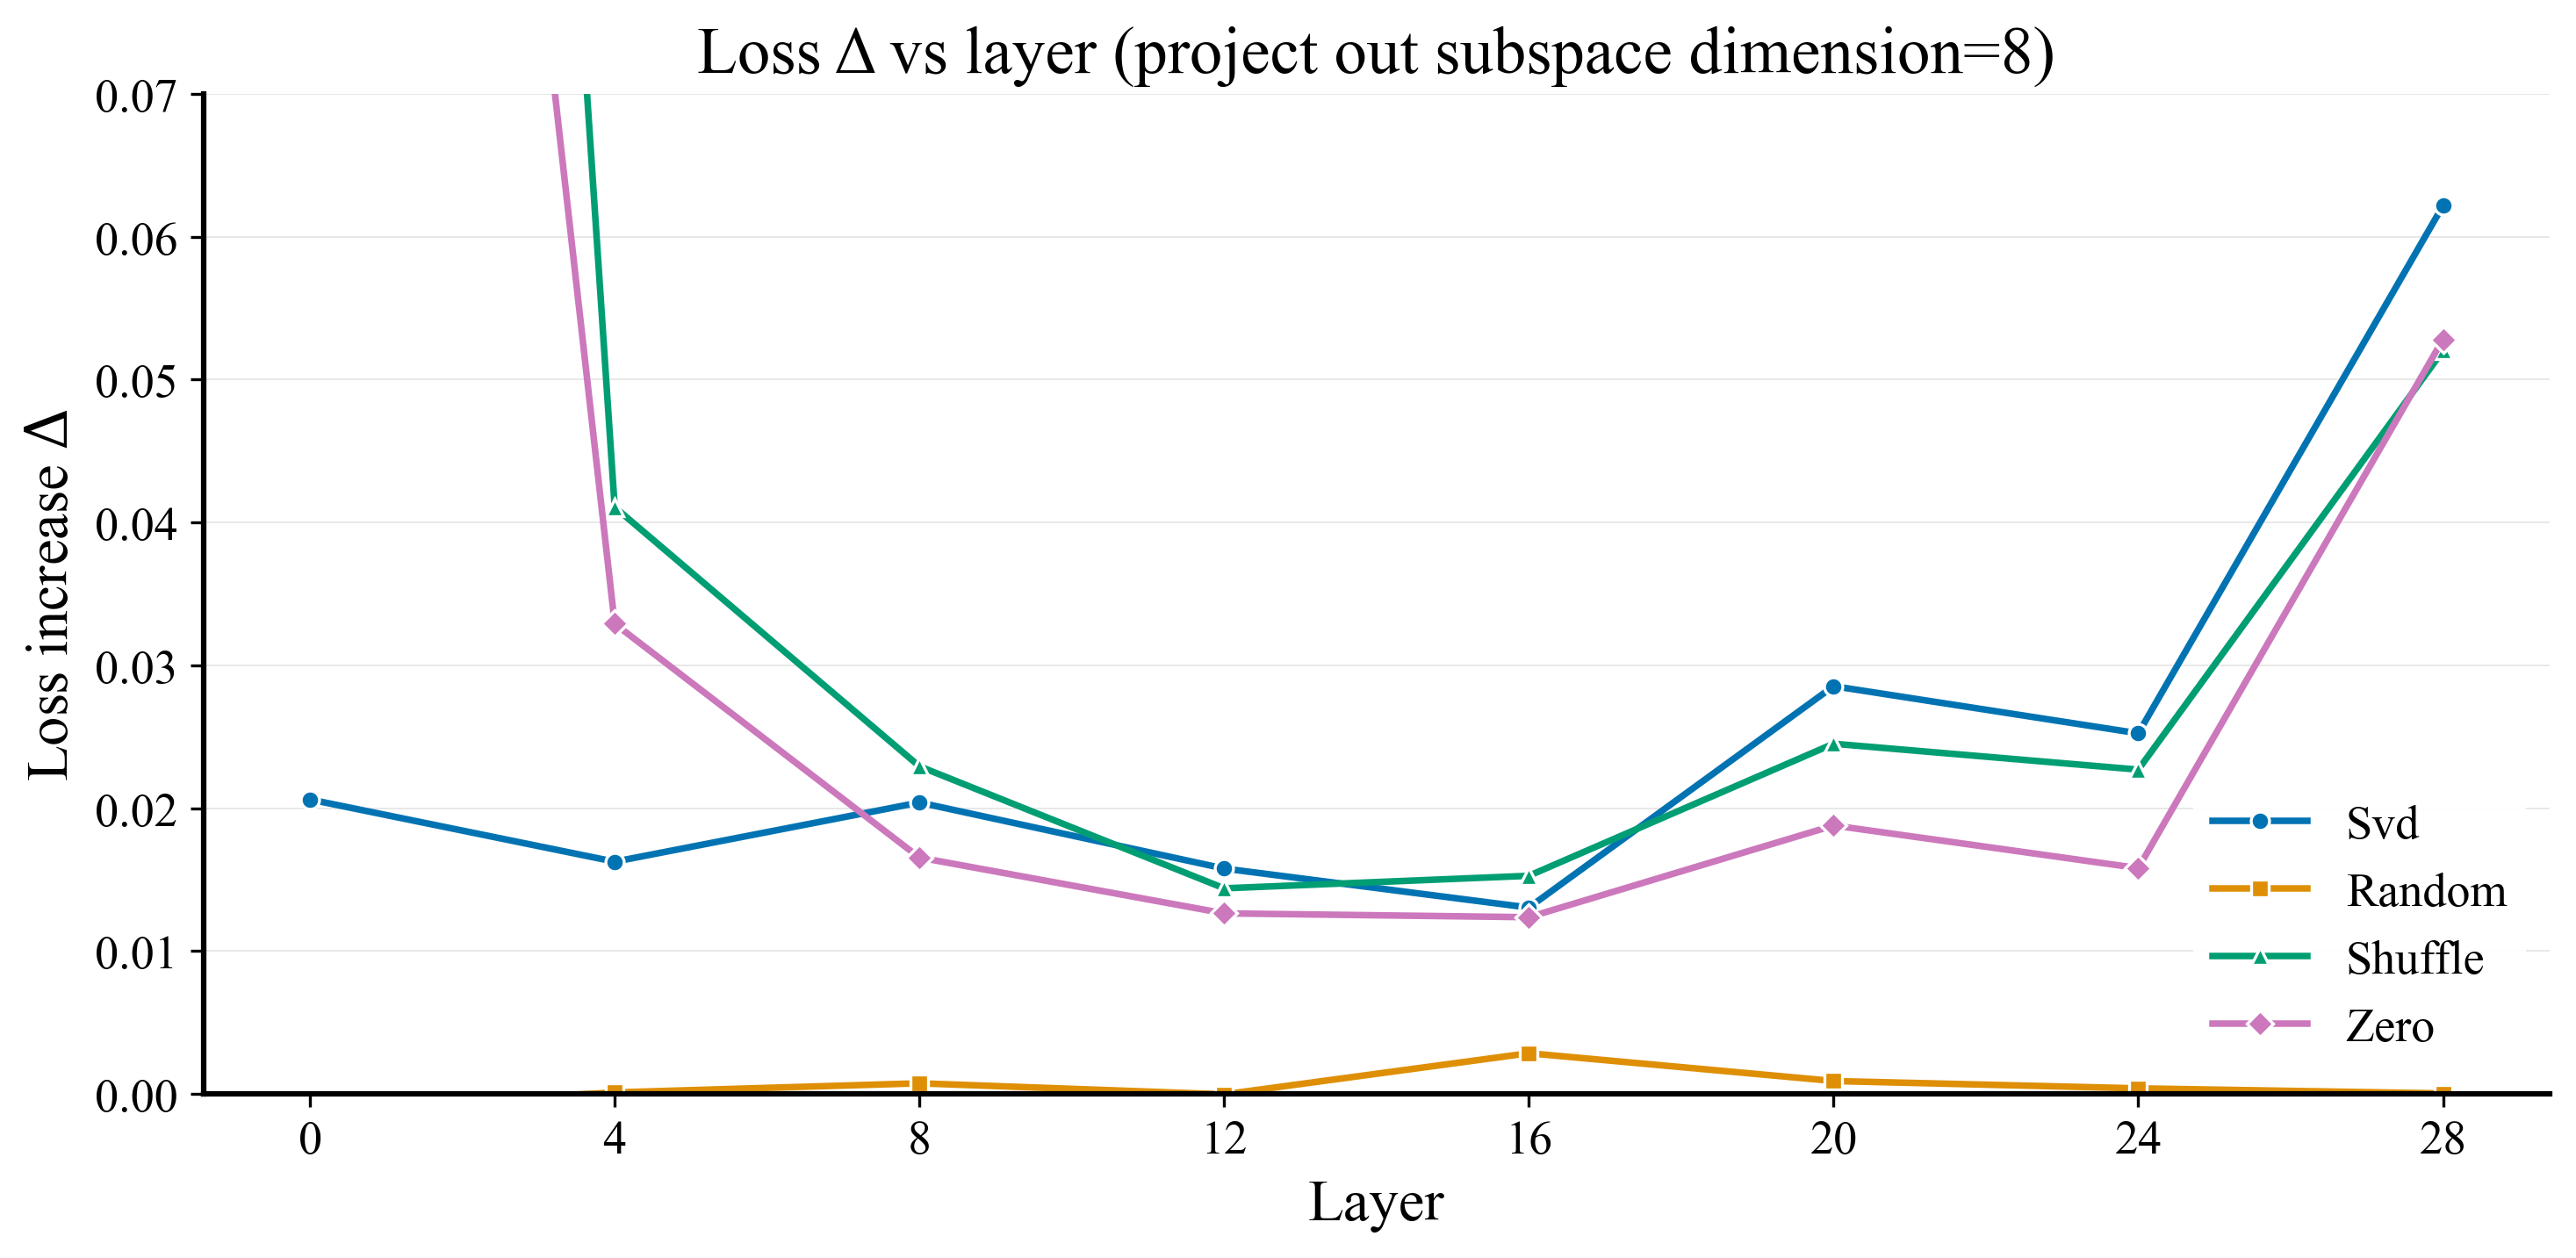

In [14]:
%matplotlib inline

fig = plot_delta_vs_layers(
    
    results_by_layer,
    K_FOR_LAYER_PLOT,
    variants=['svd', 'random', 'shuffle', 'zero'],
    title=f"Loss Δ vs layer (project out subspace dimension={K_FOR_LAYER_PLOT})",
    ylim=(0, 0.07),  # REMOVED - was cutting off zero/shuffle variants at ~1.0
    # You can add it back if you want to zoom into svd/random only
    publication_mode=True,
)
fig.show()

## 2. Plot: Loss Δ vs k (for a specific layer or multiple layers)

Load result file(s) that have multiple k values. x = k, y = loss delta.

**Usage examples:**
- Single layer: `LAYERS_TO_PLOT = [0]` - plots only layer 0
- Multiple layers: `LAYERS_TO_PLOT = [0, 1, 2, 3]` - compares layers 0-3 on same chart
- All layers: `LAYERS_TO_PLOT = None` - plots all available layers together

This allows you to:
- Compare how different layers respond to the same k values
- Identify which layers are most/least sensitive to interventions
- Zoom into specific layers of interest

In [4]:
# Choose which layer(s) to plot. Options:
# 1. Single layer: LAYERS_TO_PLOT = [0]  
# 2. Multiple layers: LAYERS_TO_PLOT = [0, 1, 2]
# 3. All available: LAYERS_TO_PLOT = None

LAYERS_TO_PLOT = [0,4,8,12,16,20,24,28]  # Set to None for all layers or specify [0, 1, 2, etc.]

# Load data for the selected layers
if LAYERS_TO_PLOT is None:
    # Load all available result files
    layer_results = {r.get("config", {}).get("layer_idx"): r 
                     for r in results_by_layer}
else:
    # Load specific layers
    layer_results = {}
    for layer_idx in LAYERS_TO_PLOT:
        for r in results_by_layer:
            if r.get("config", {}).get("layer_idx") == layer_idx:
                layer_results[layer_idx] = r
                break

# Show what we loaded
print(f"Loaded layers: {sorted(layer_results.keys())}")
if layer_results:
    sample_result = next(iter(layer_results.values()))
    print(f"by_k keys: {list(sample_result.get('by_k', {}).keys())}")


Loaded layers: [0, 4, 8, 12, 16, 20, 24, 28]
by_k keys: ['1', '4', '8', '32', '128', '256', '512']


/var/folders/y_/lbn7h_sj0bl553hrsqbml1zc0000gp/T/ipykernel_35934/2986081970.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


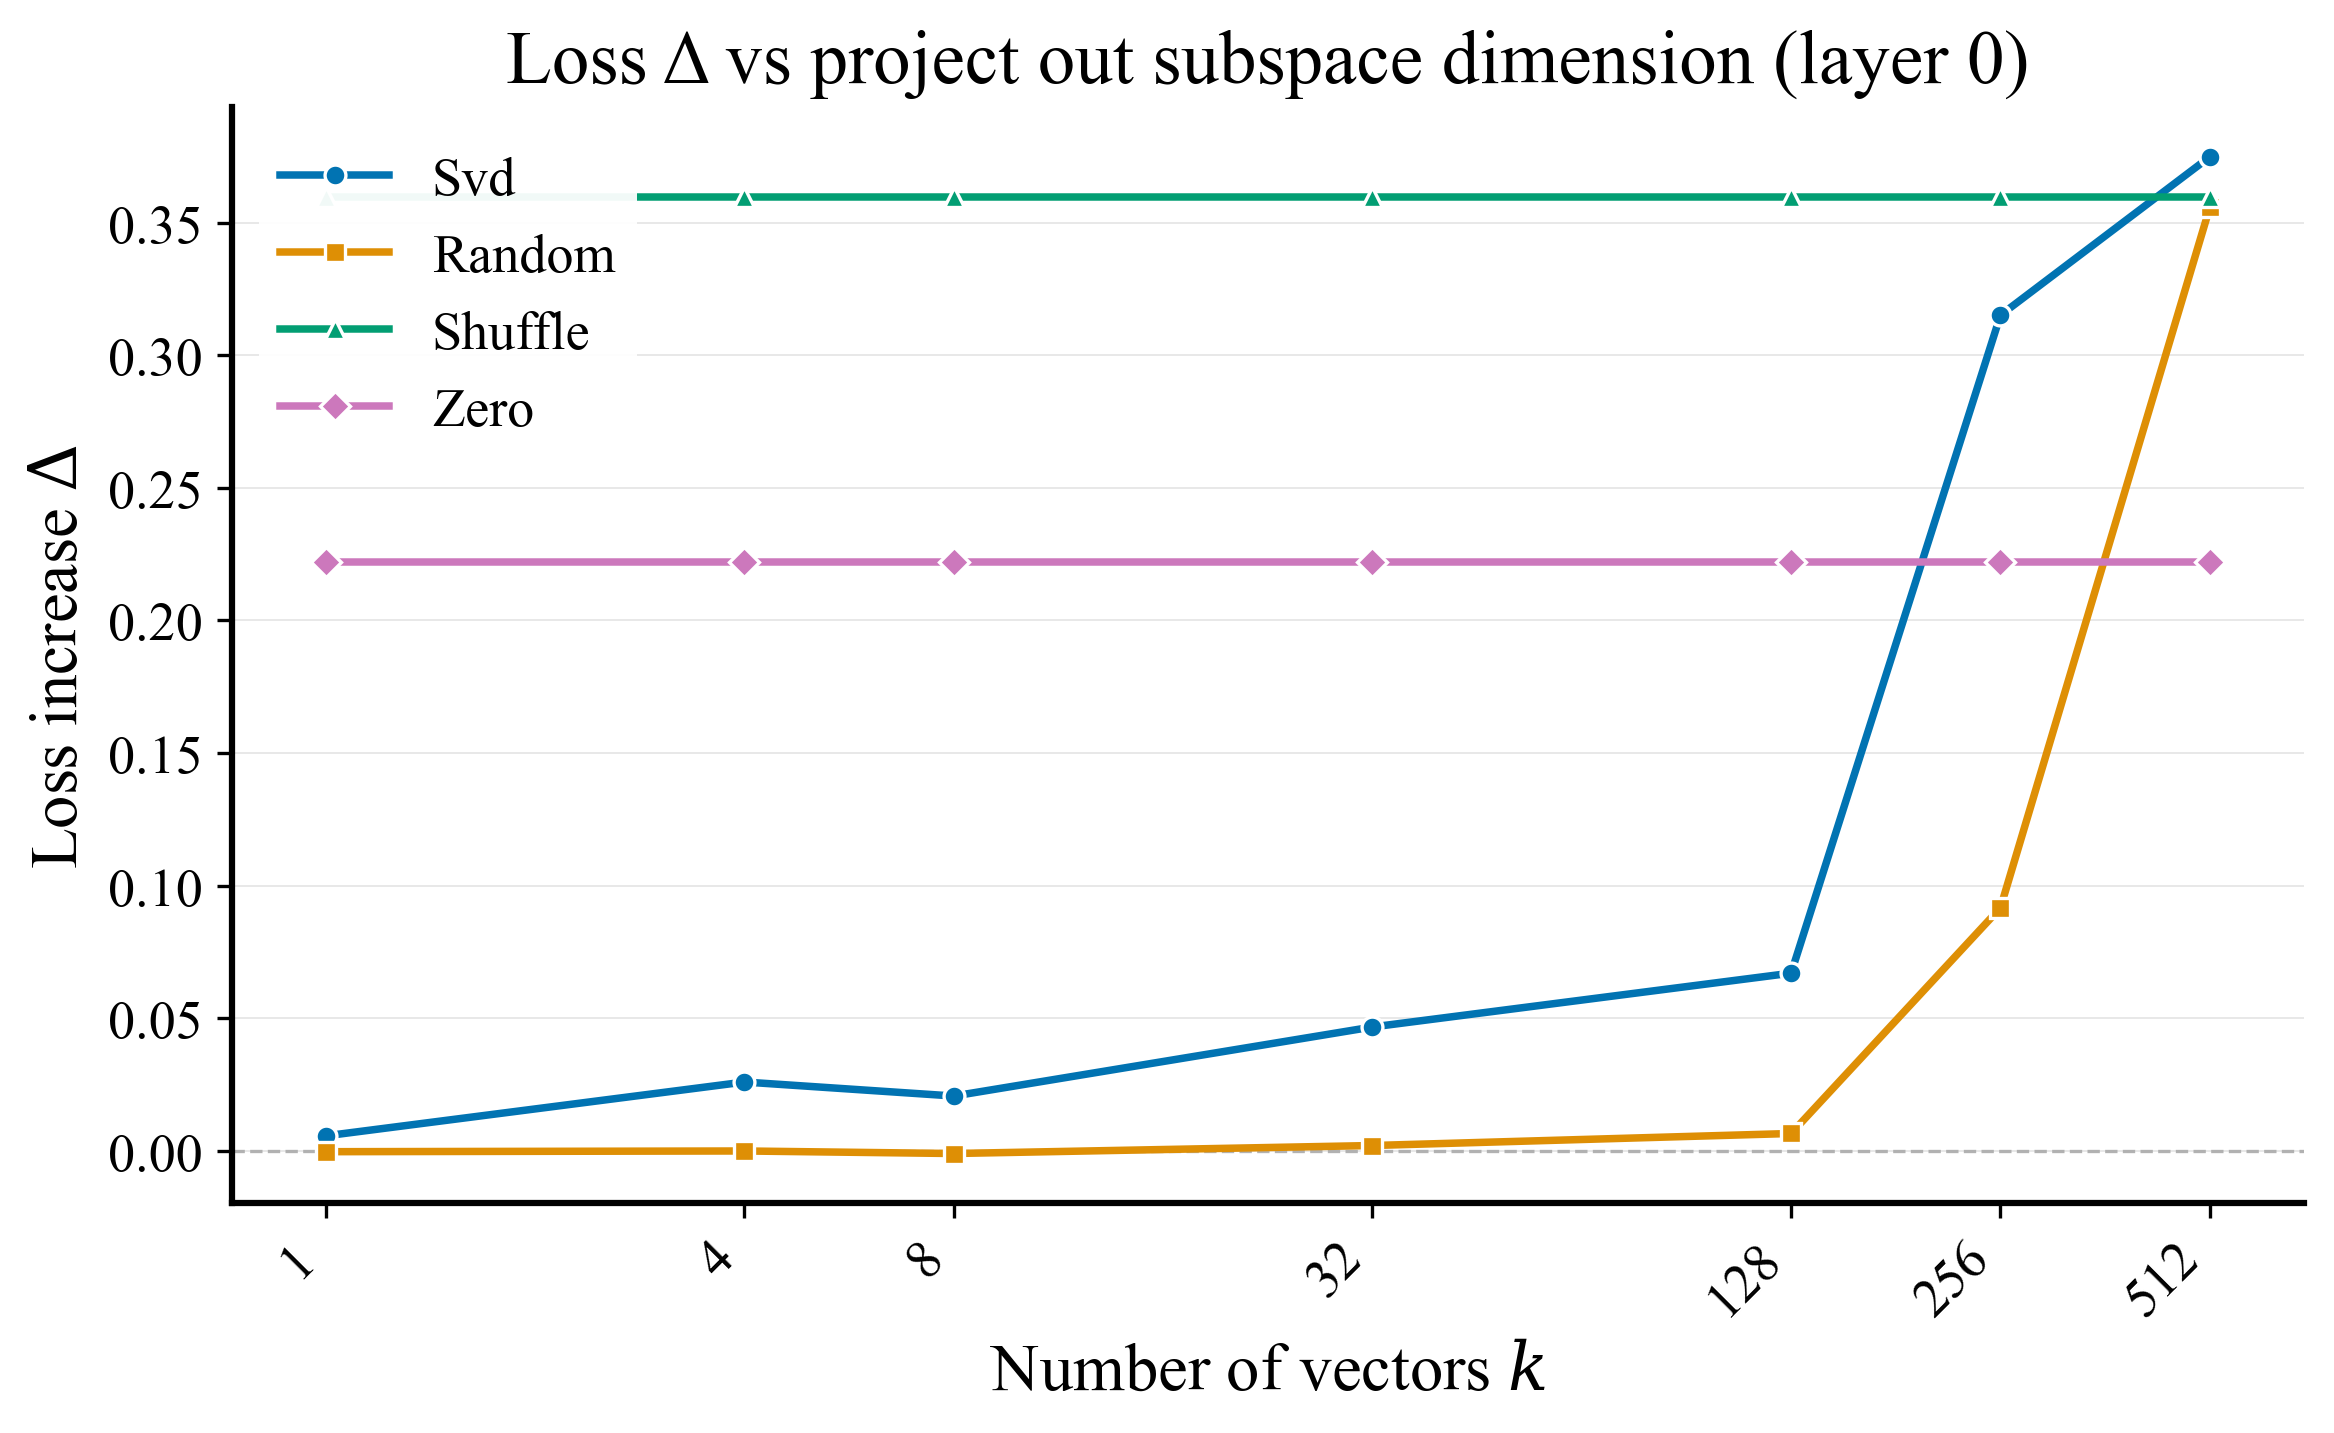

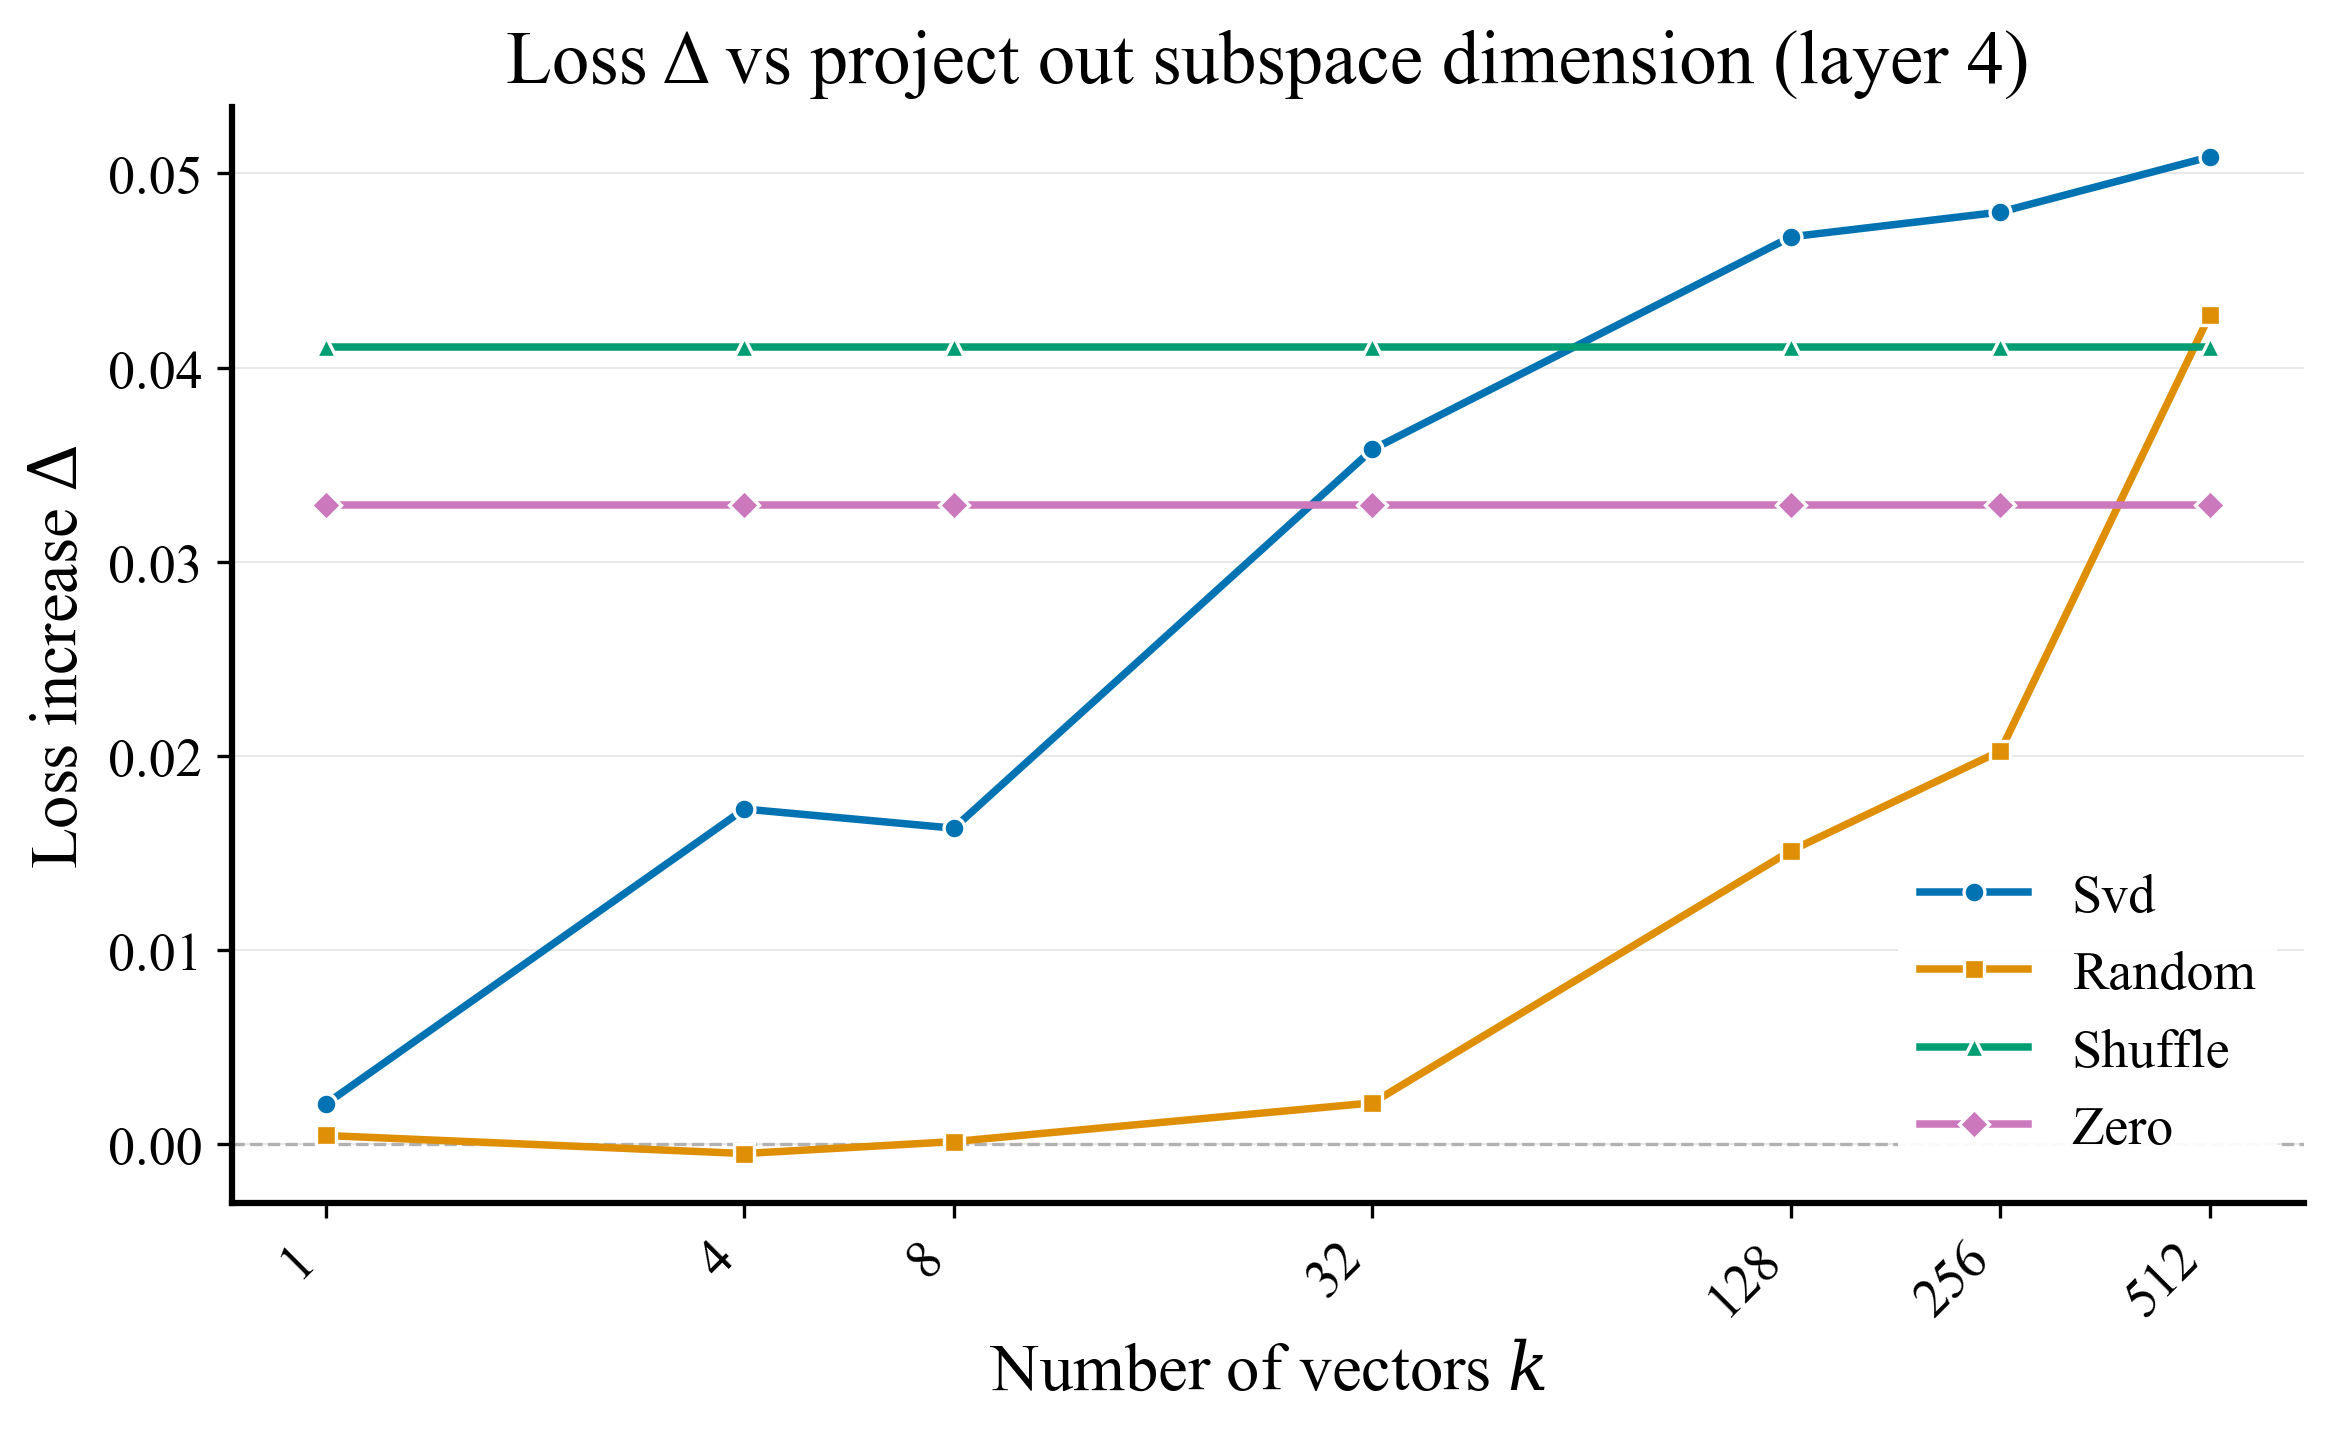

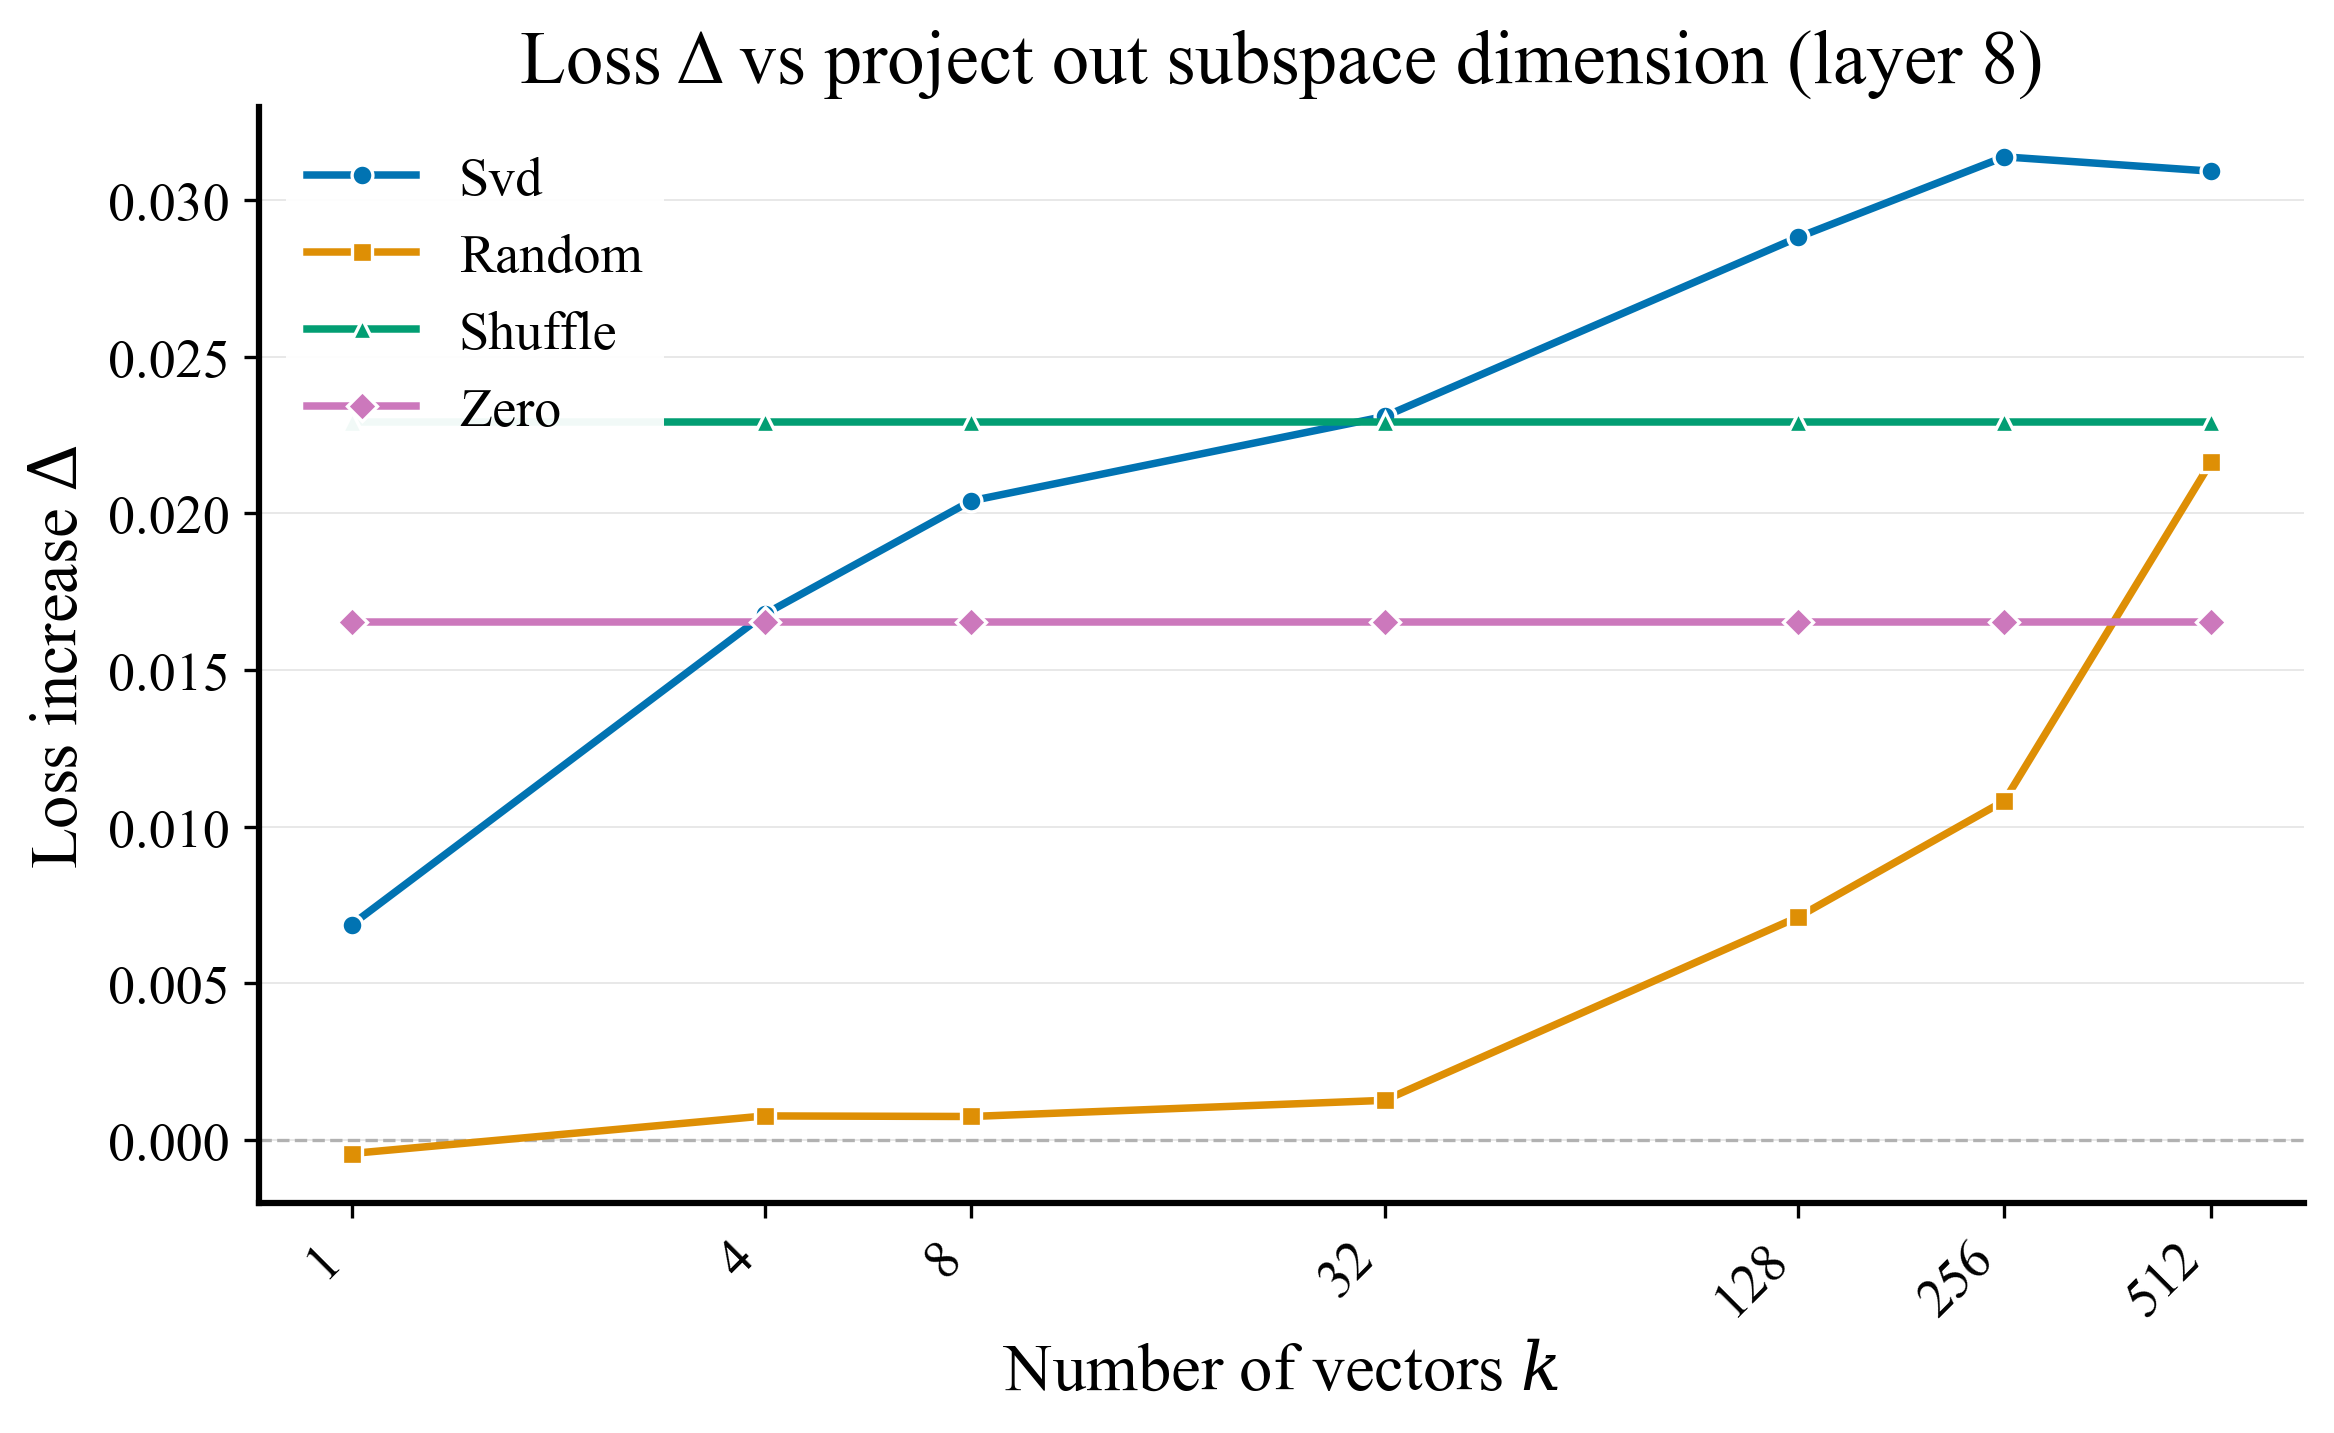

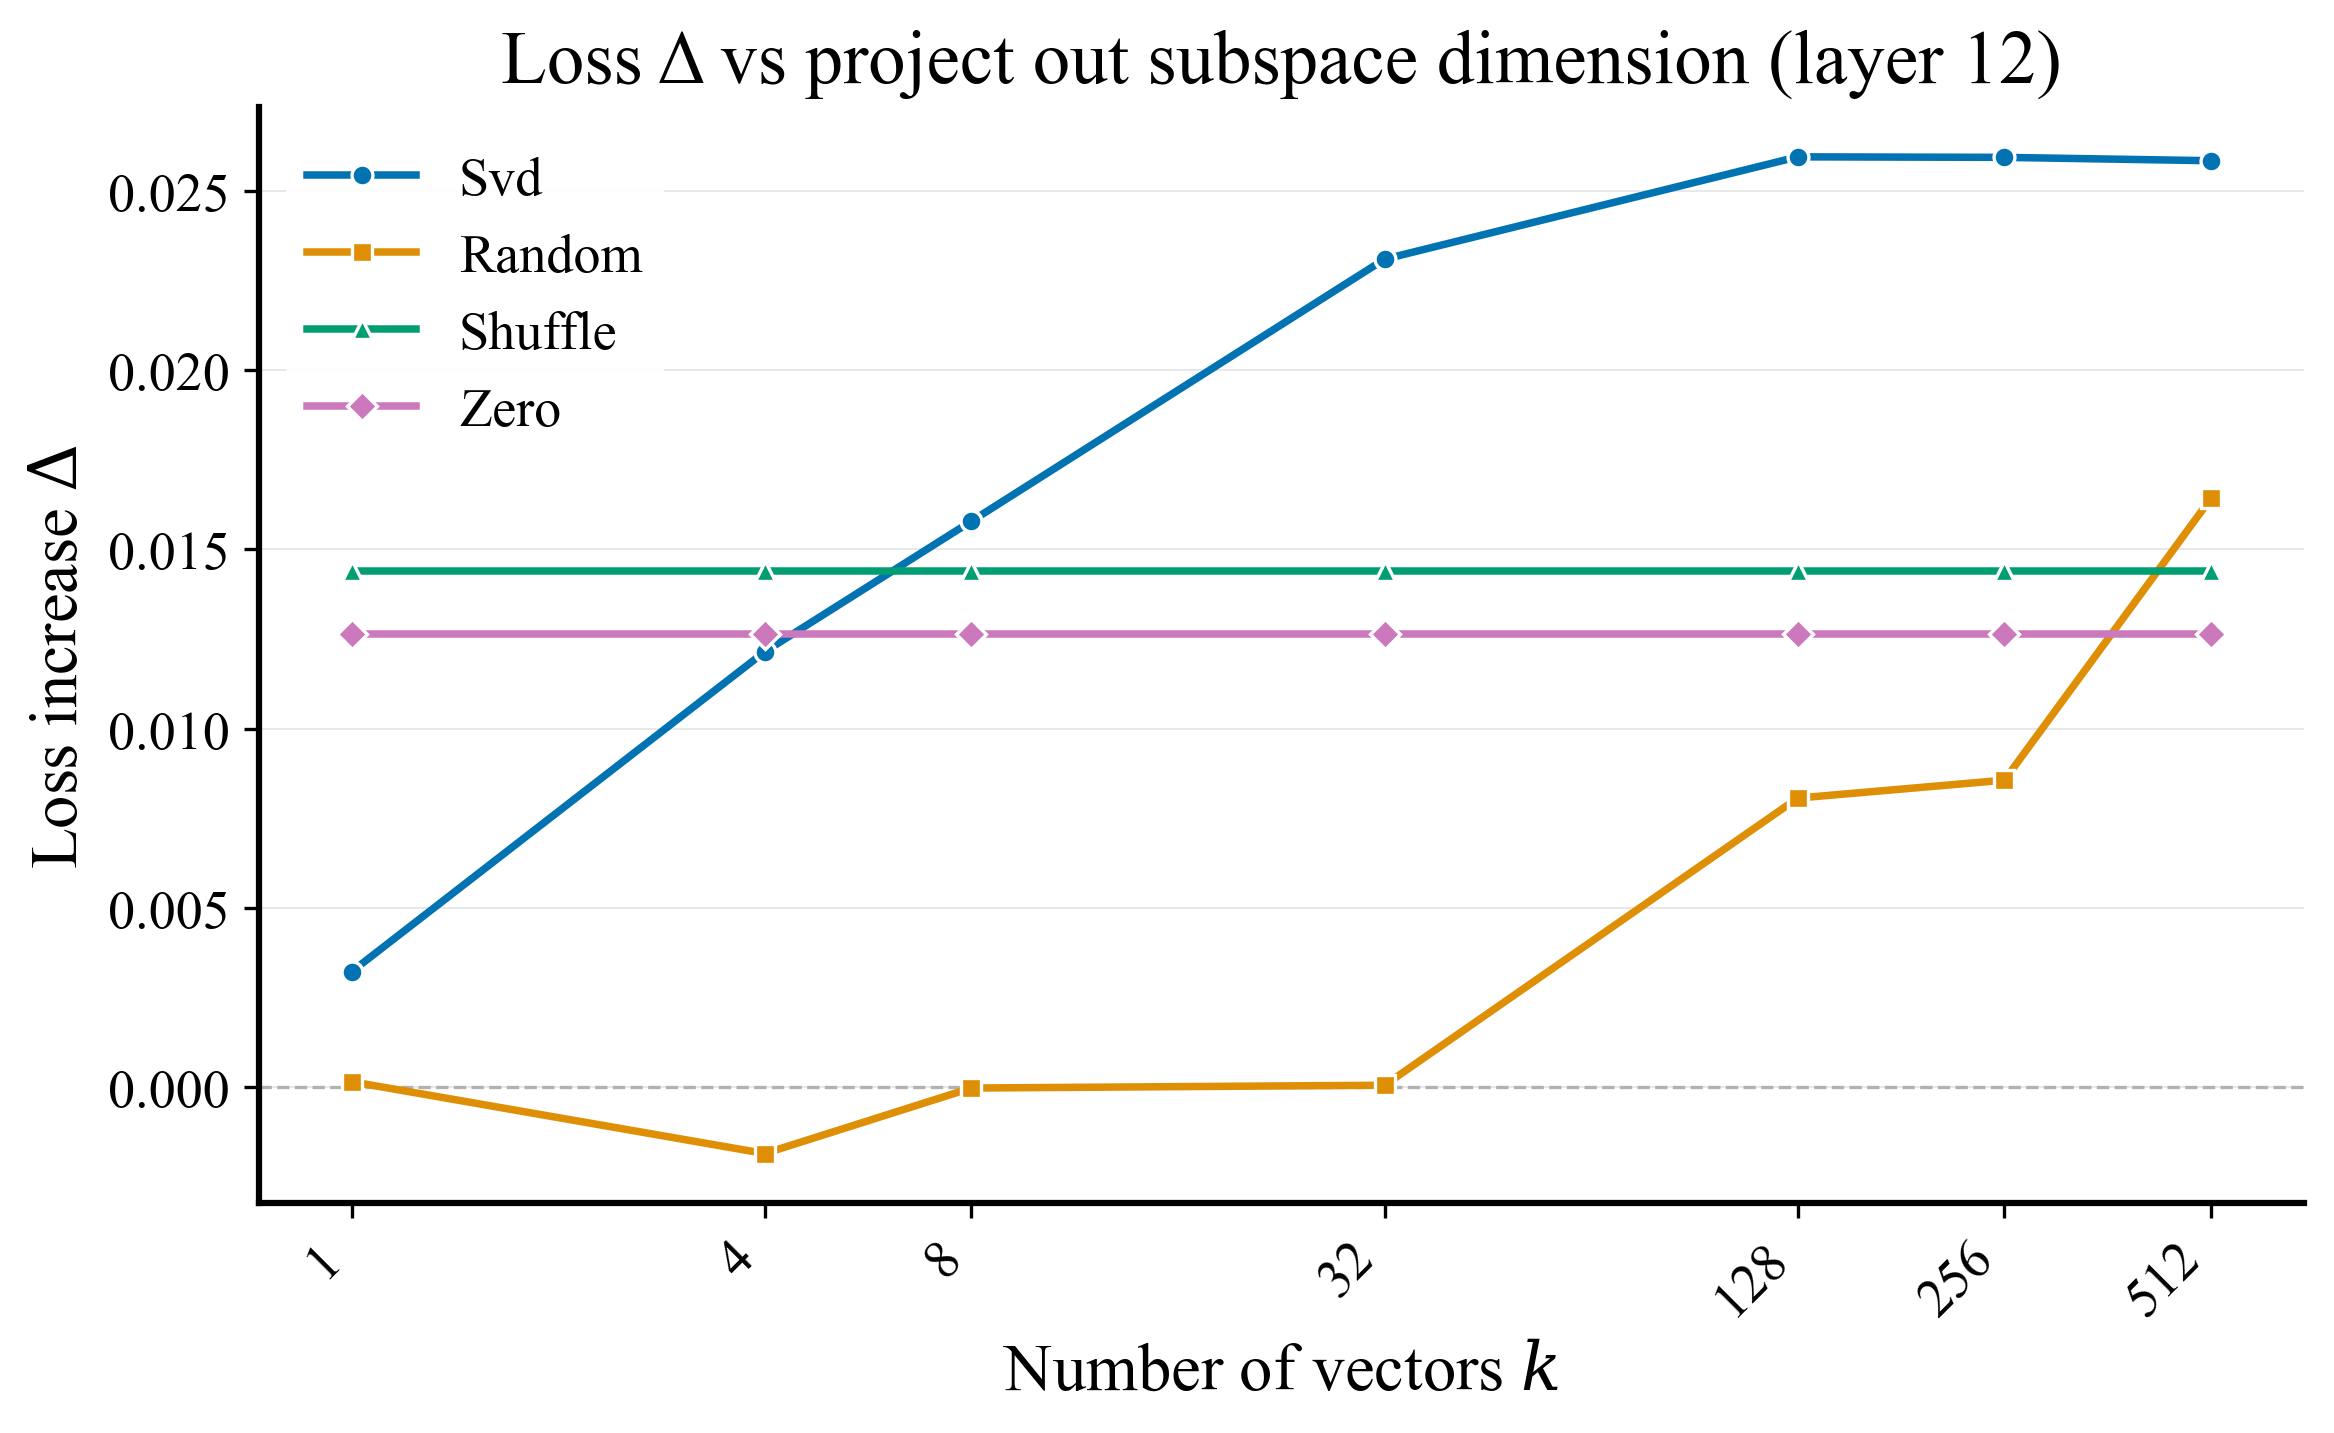

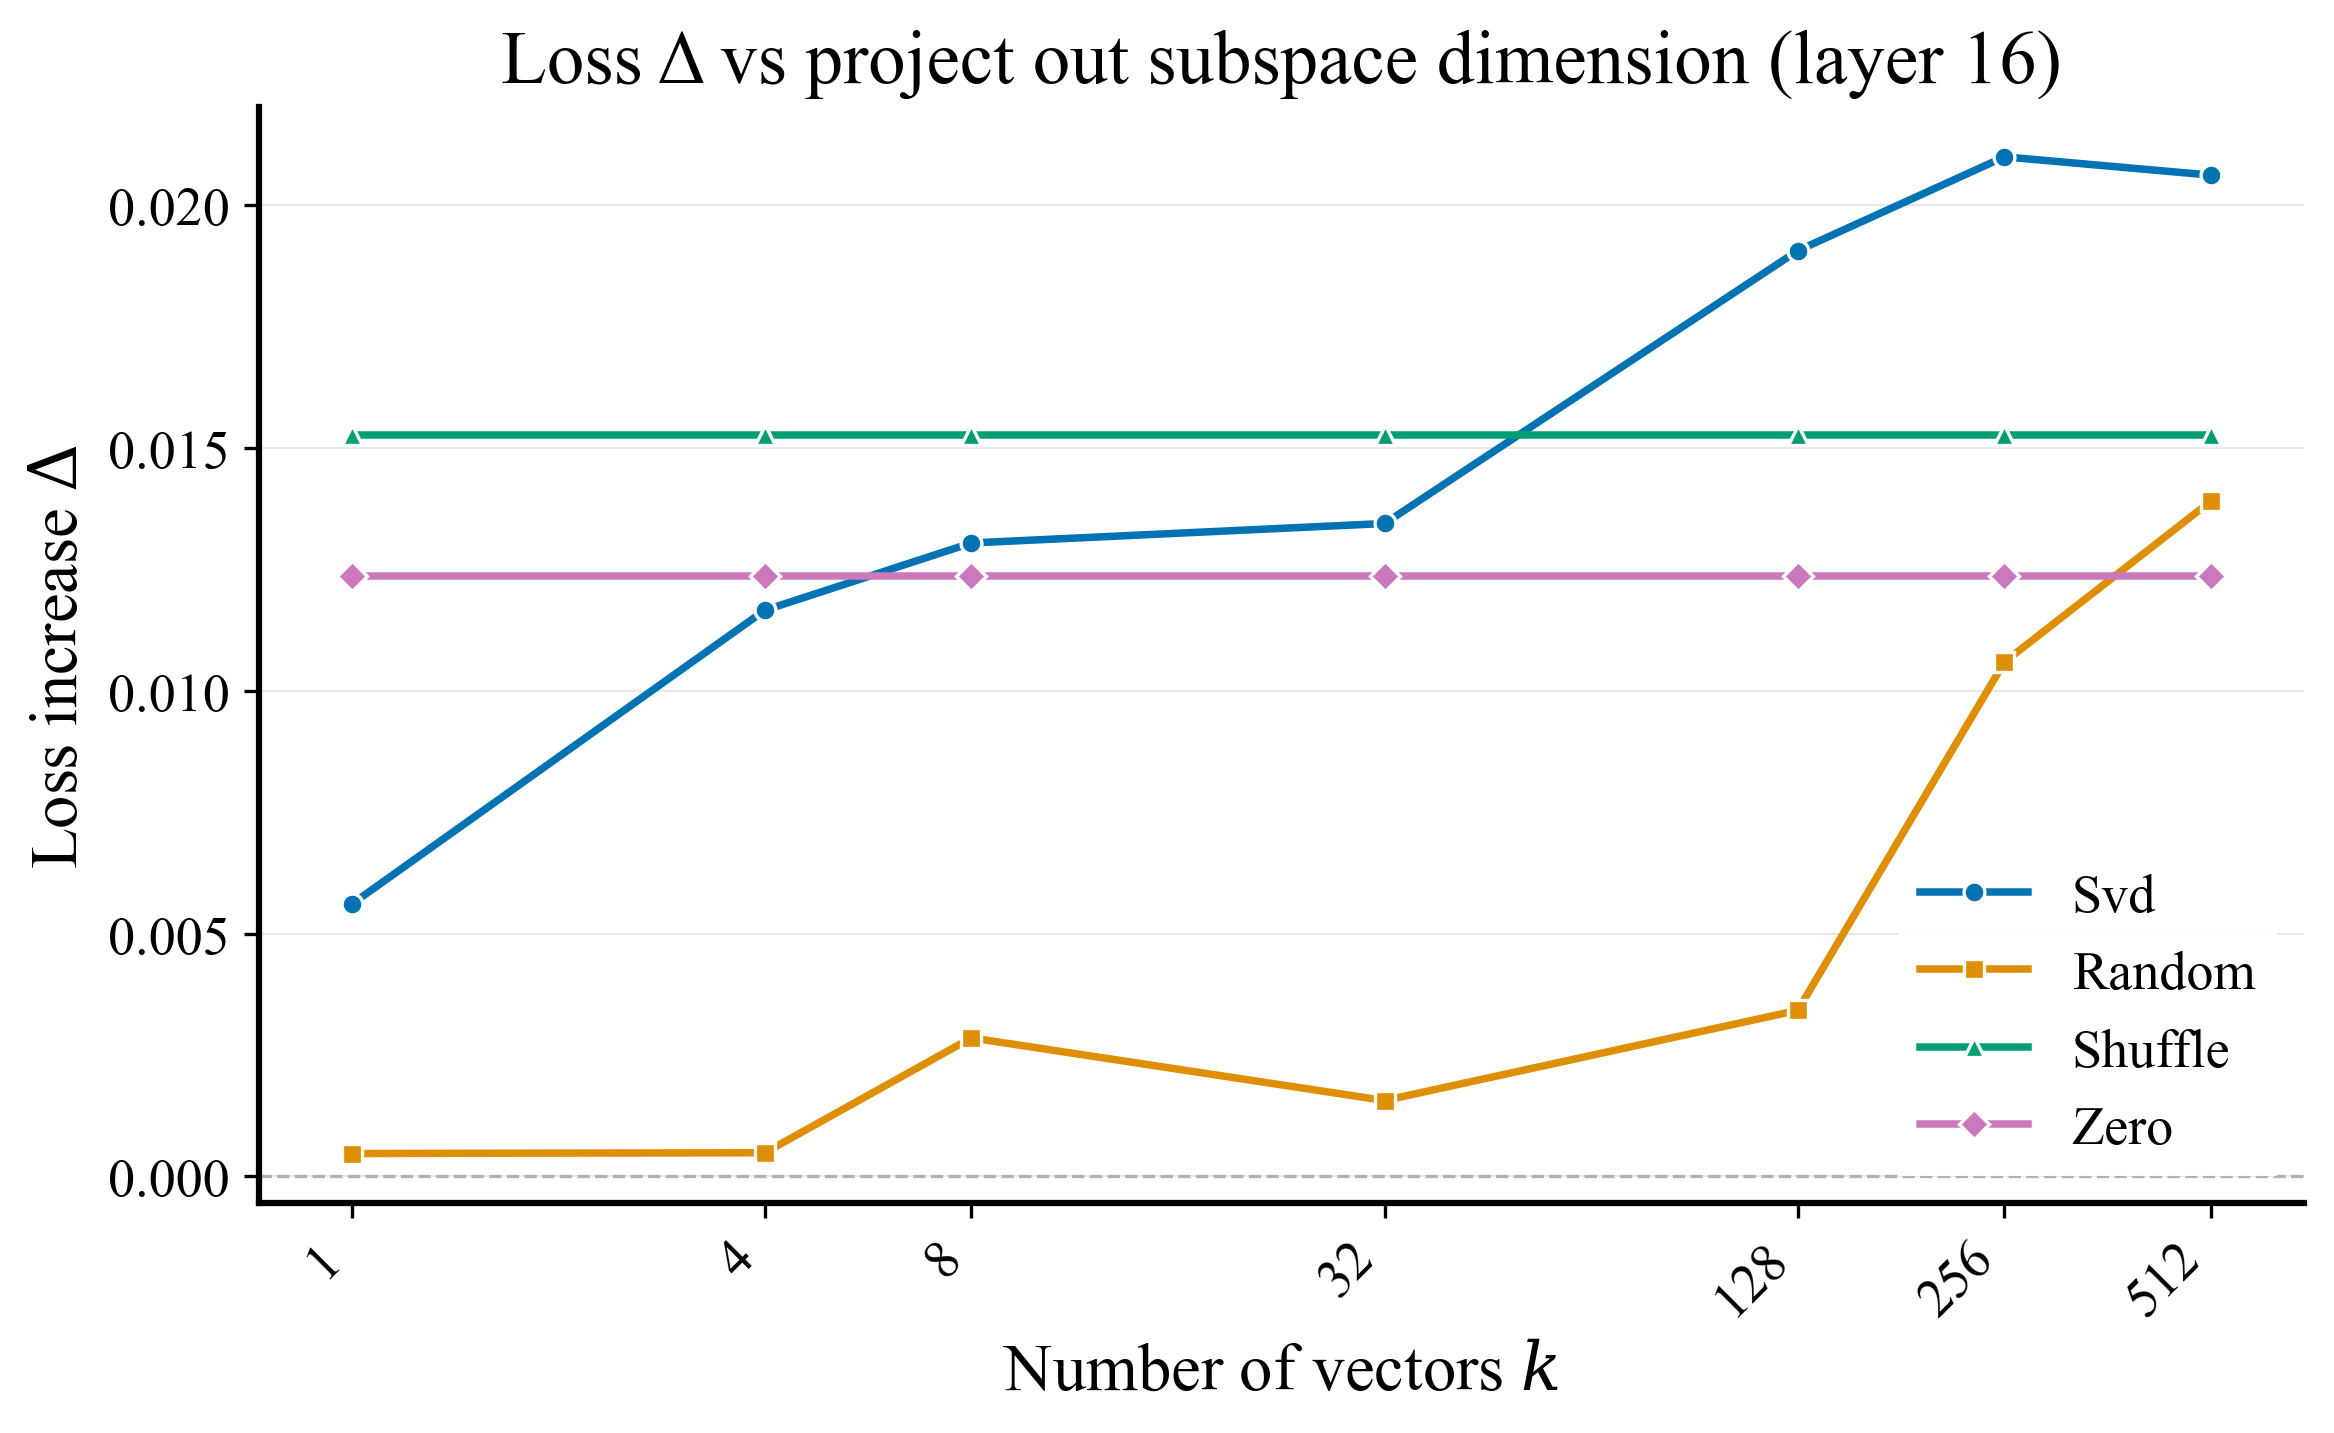

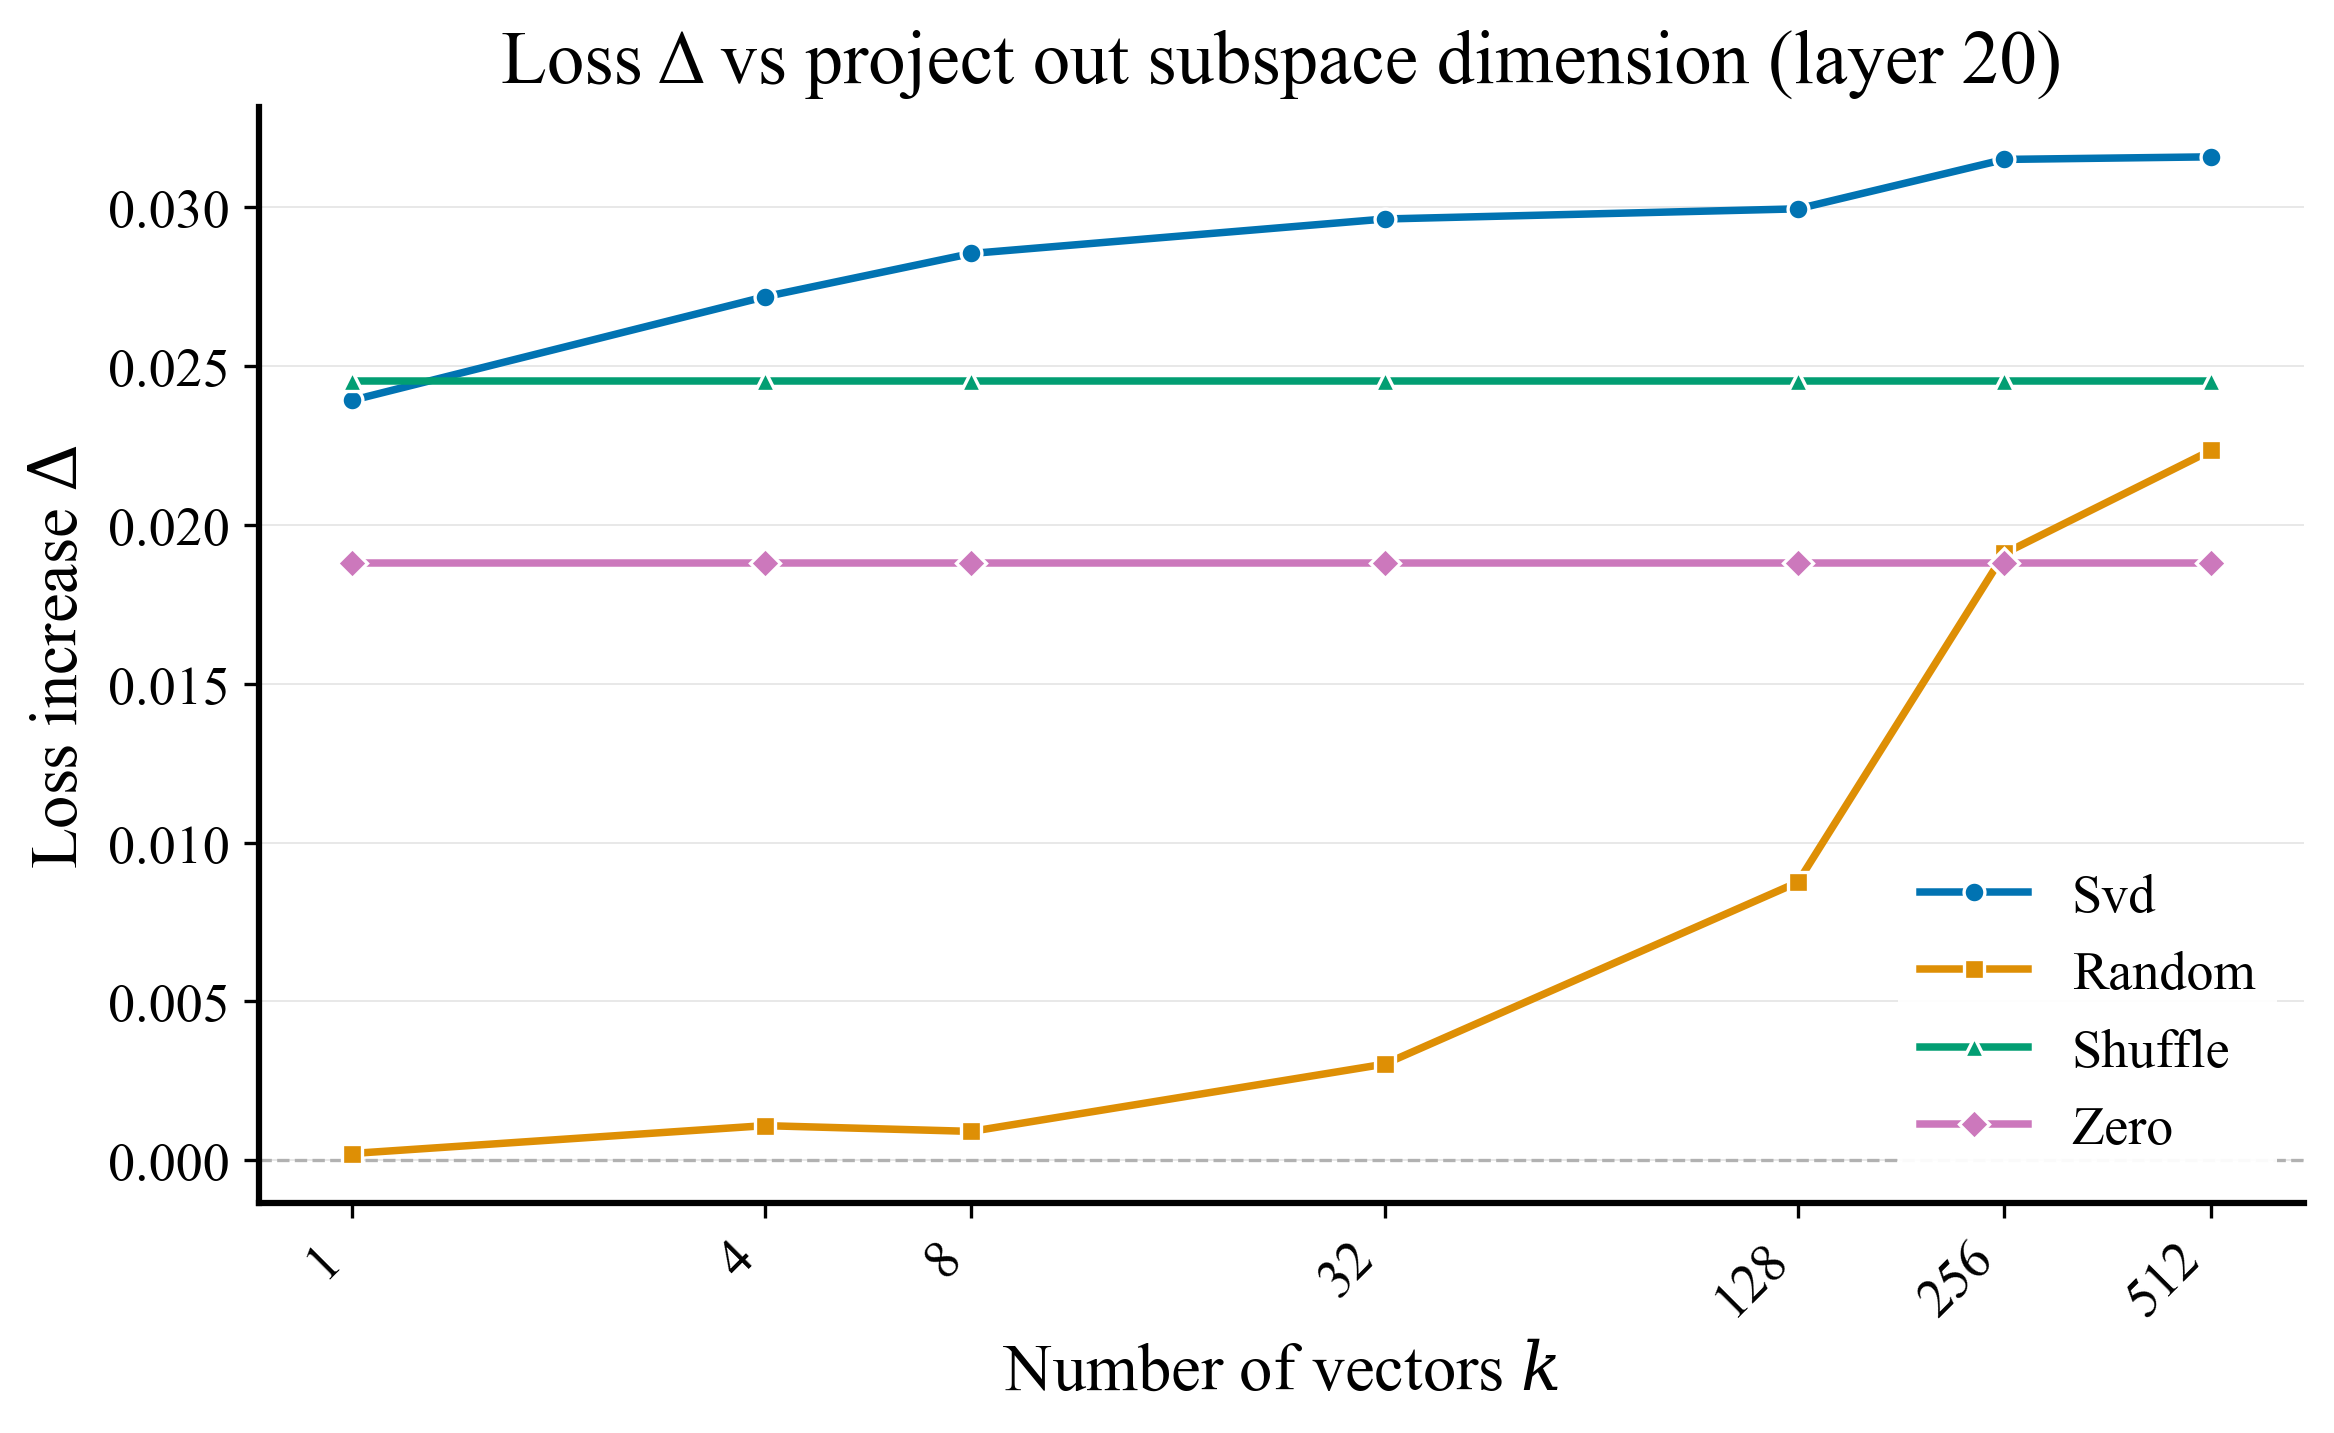

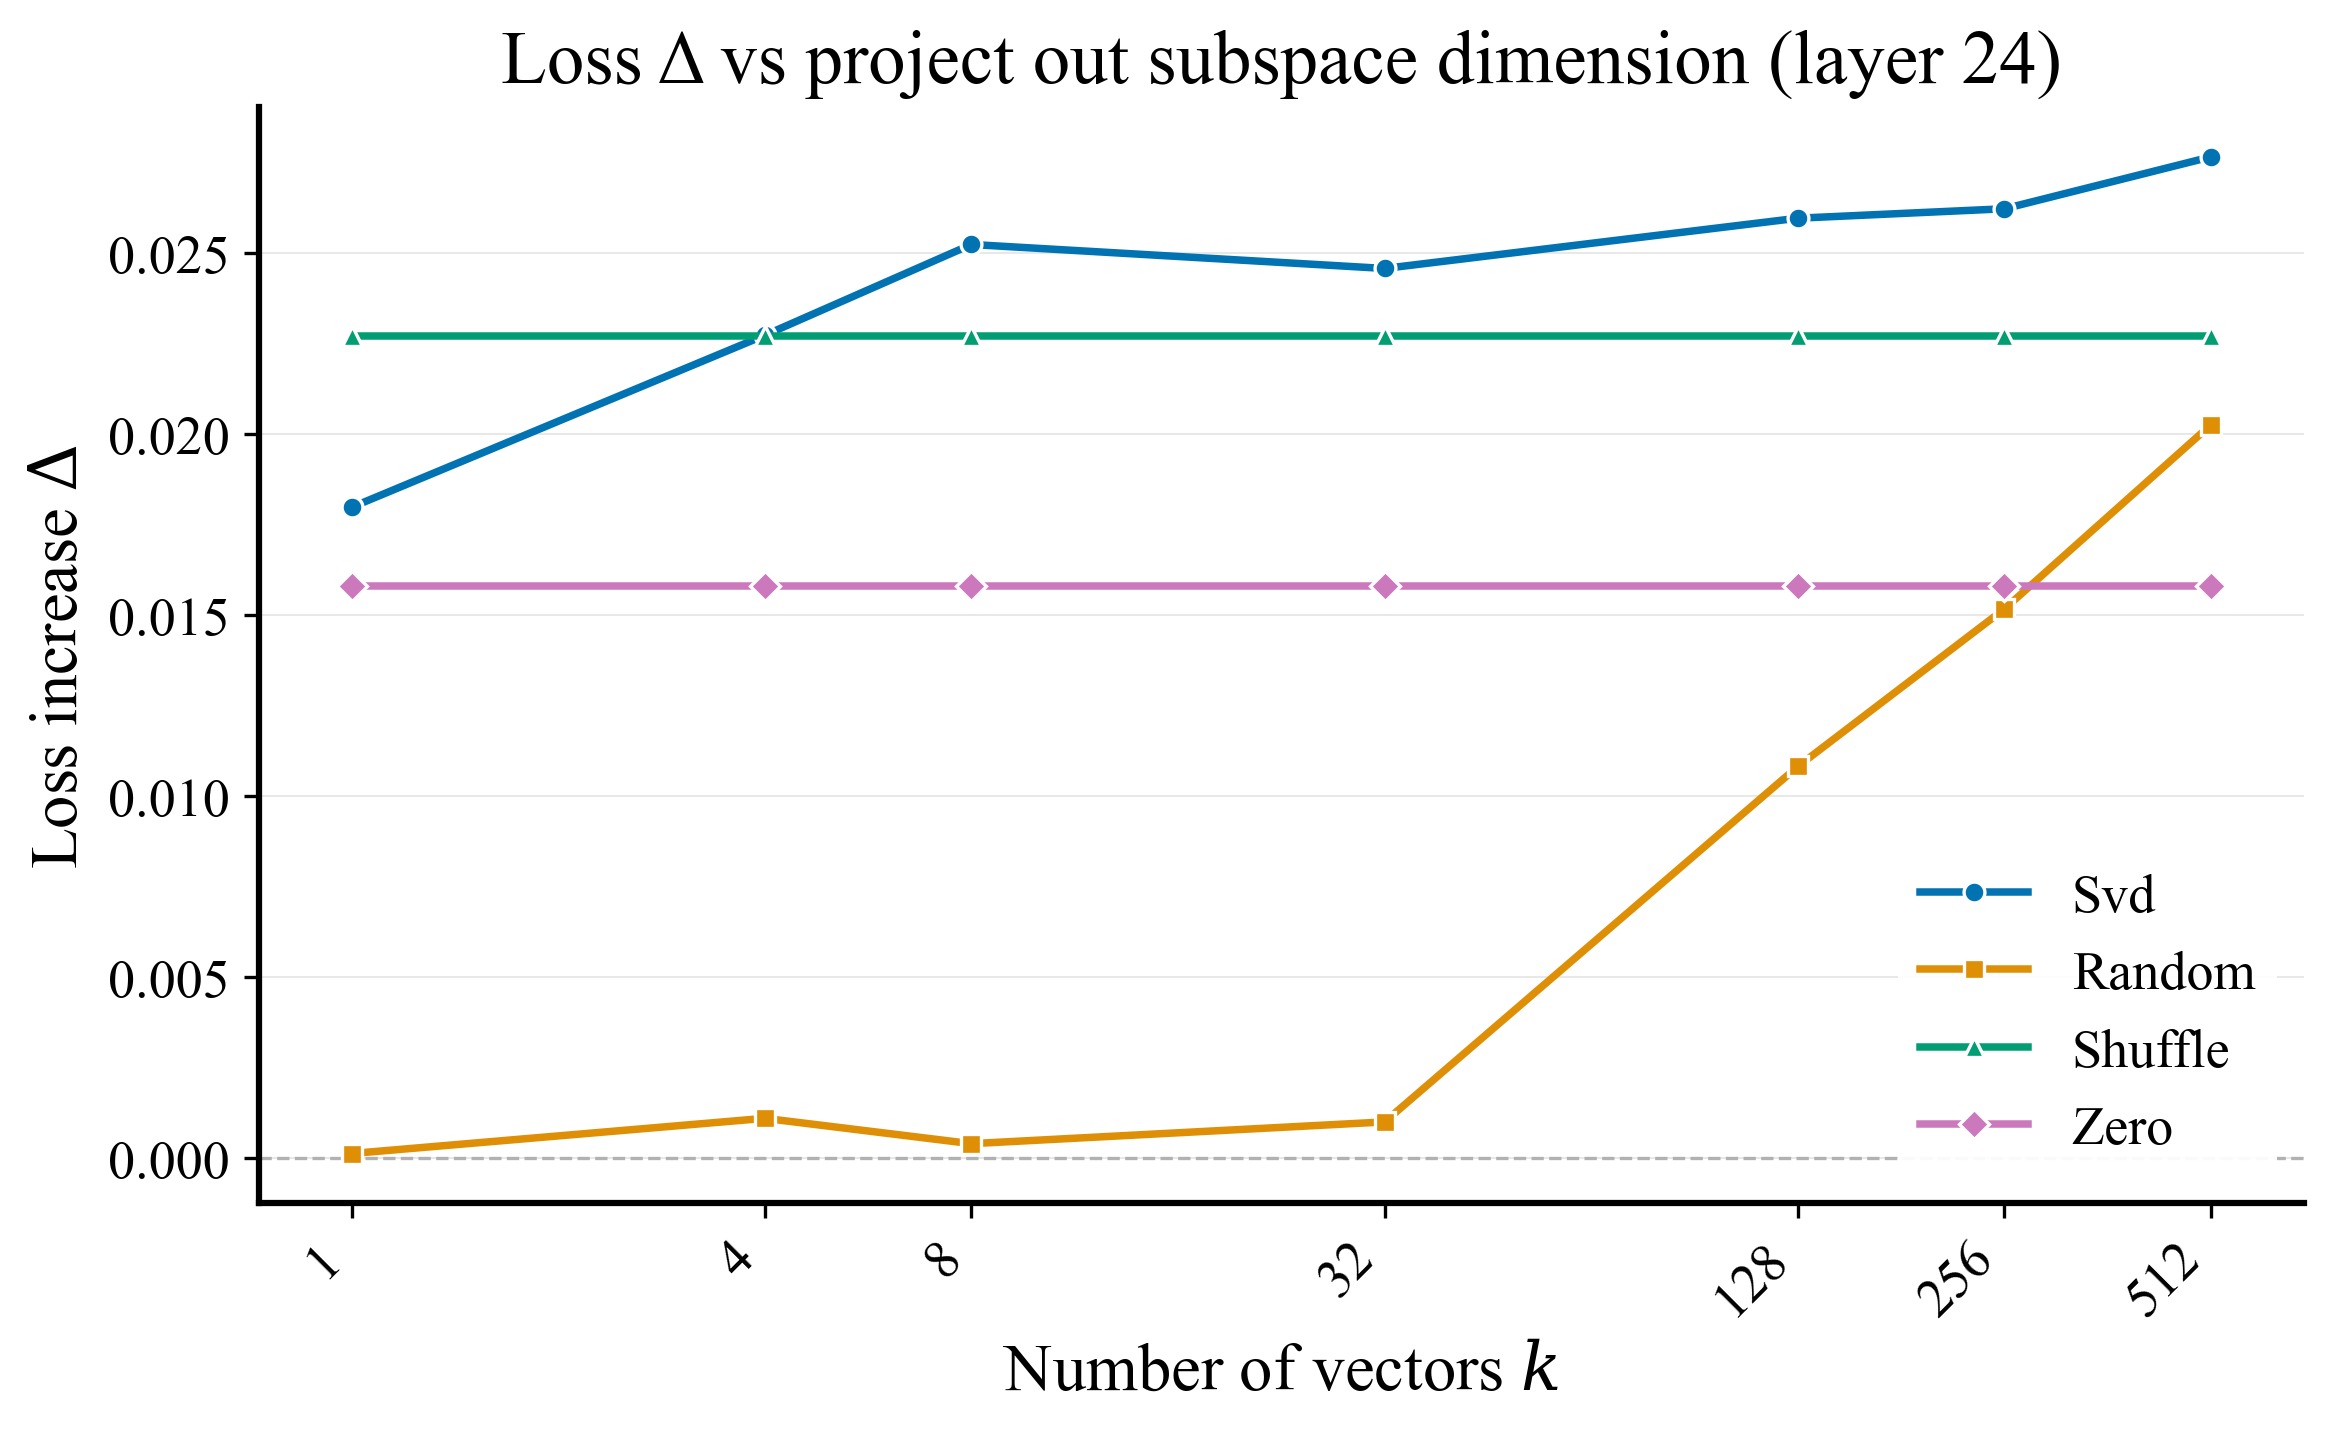

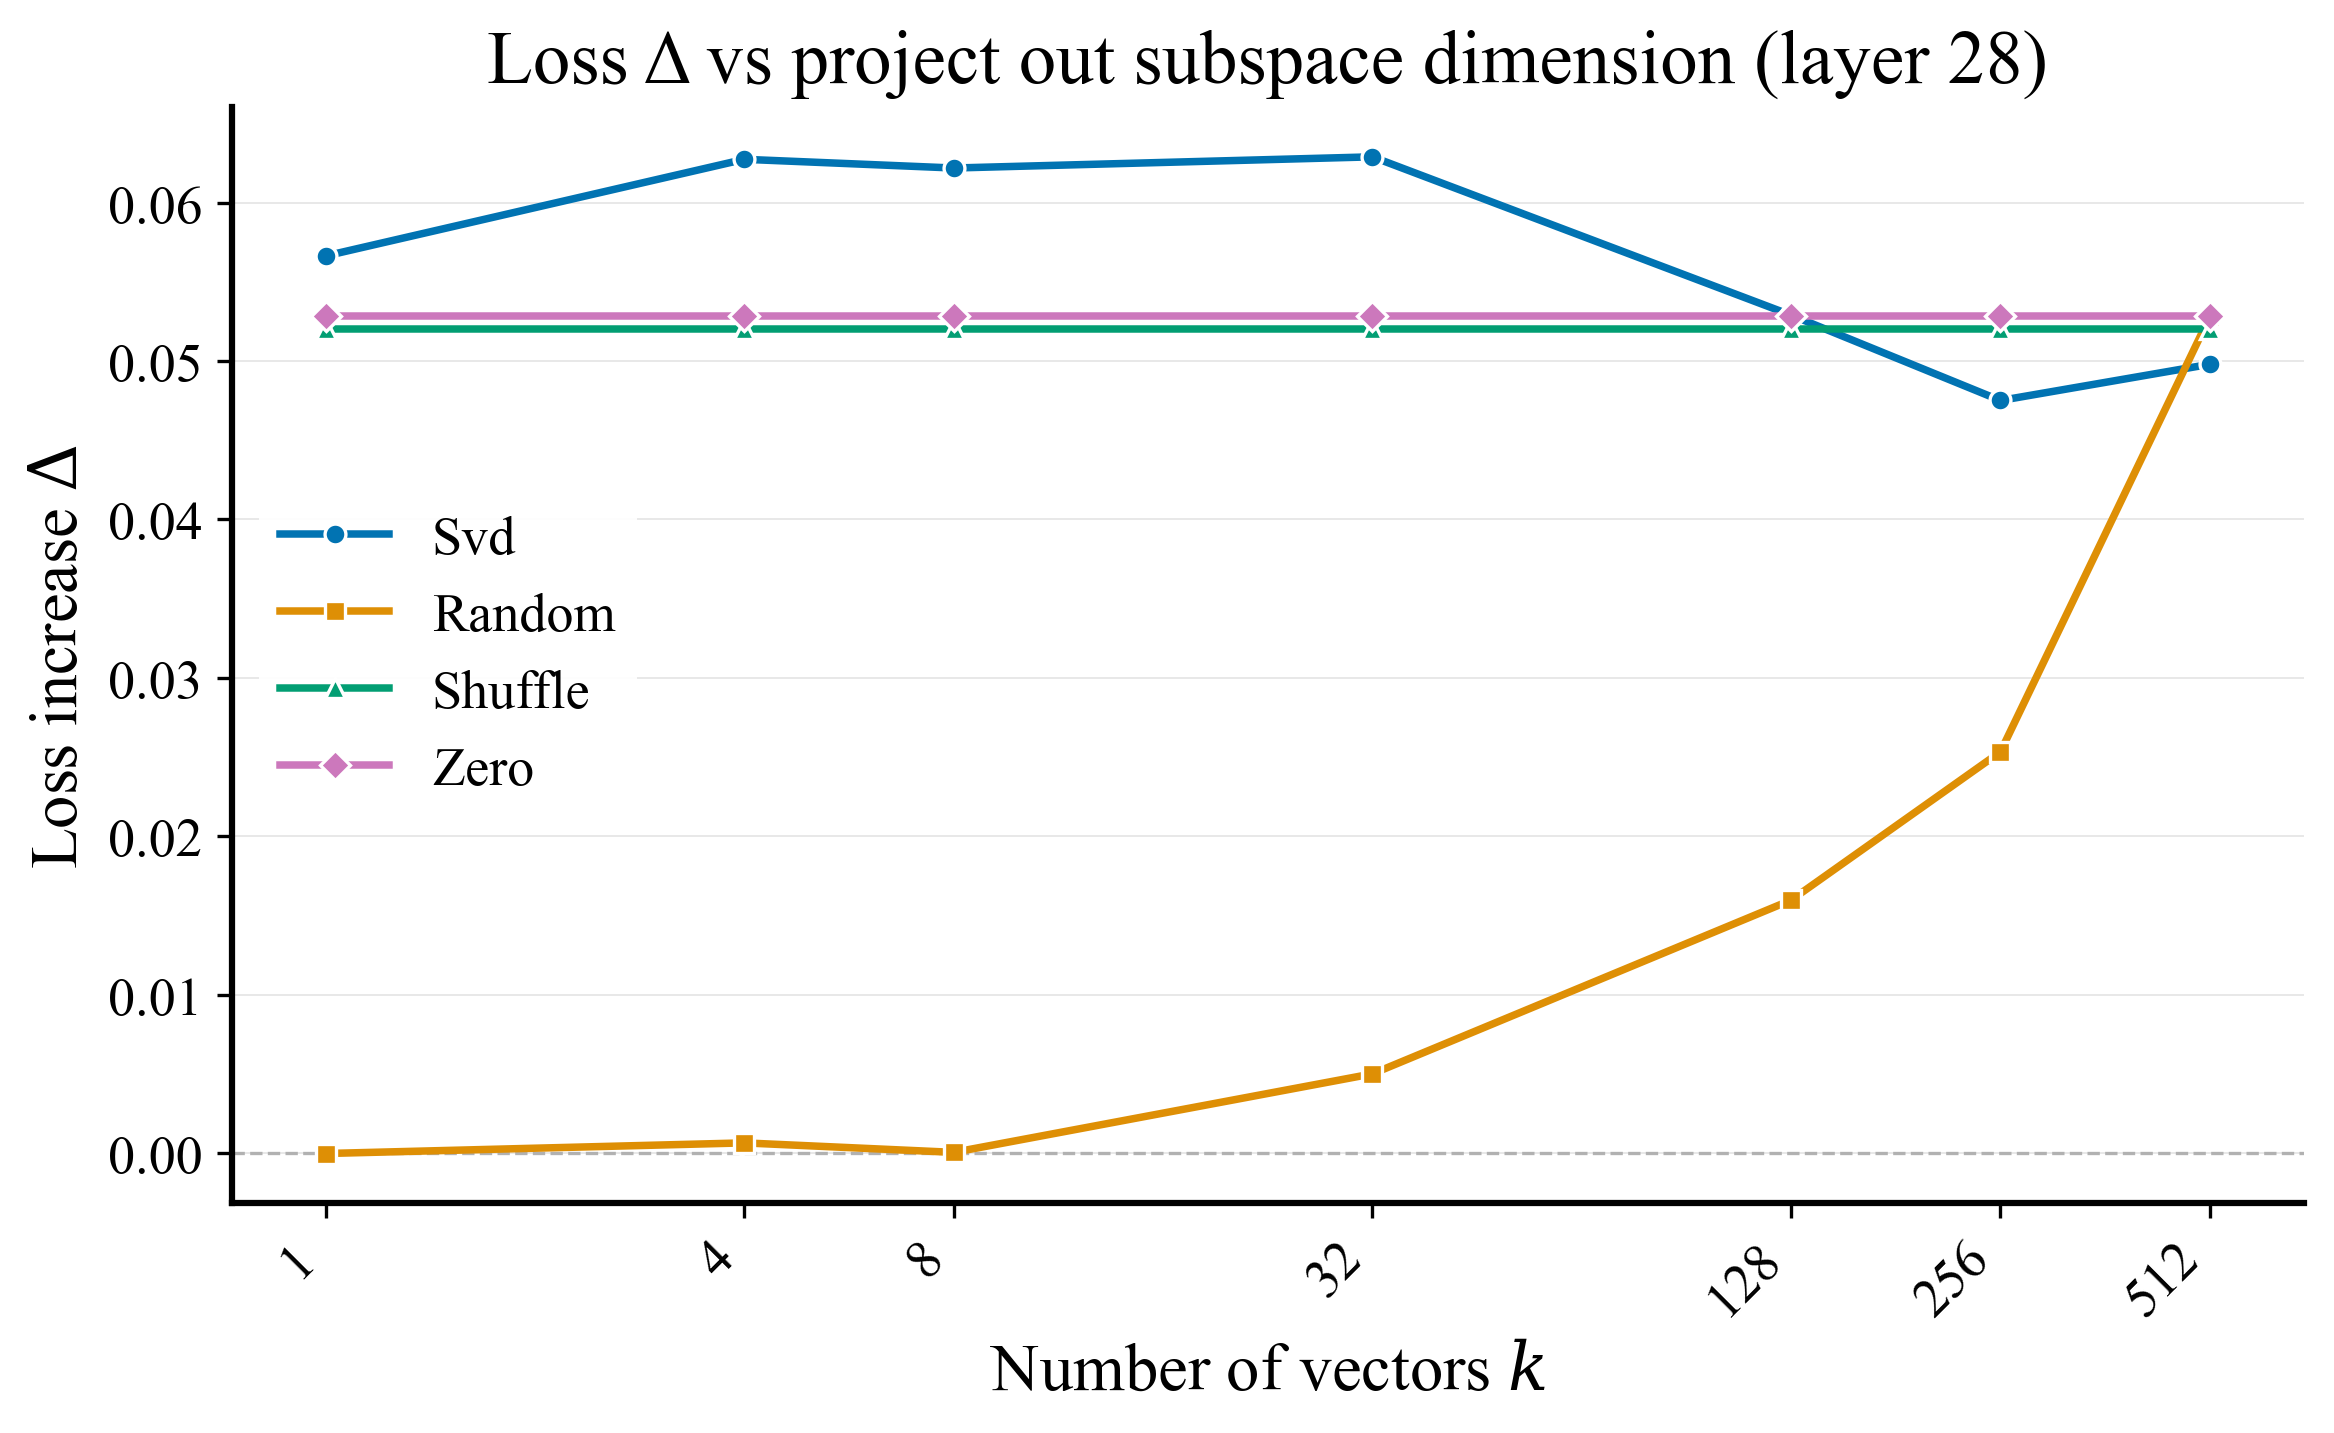

In [15]:
for layer in layer_results:
    fig2 = plot_delta_vs_k(
        layer_results[layer],
        variants=['svd', 'random', 'shuffle', 'zero'],
        title=f"Loss Δ vs project out subspace dimension (layer {layer})",
        publication_mode=True,
    )
    fig2.show()

# Publication-Quality Figures

The plotting functions now have improved defaults with:
- Clean, readable axis labels (log scale for many k values)
- Better legend placement
- Professional colors and markers
- Proper aspect ratios (8:5 default)

For papers, use `figsize=(8, 5)` or adjust `ylim` to focus on interesting ranges.

In [6]:
# ACL-style figures: use plot_delta_vs_k_acl and plot_delta_vs_layers_acl (imported above).
# They export PDF with embedded fonts (vector, crisp). Set use_tex=True for LaTeX-rendered
# labels to match the paper font (requires pdflatex). Column widths: single=3.25", double=6.75".

## Save Publication Figure (PDF)

In [7]:
# ACL-style figure: PDF with embedded fonts (vector), column width, serif or LaTeX
# use_tex=True requires pdflatex and matches paper font; use_tex=False uses serif + embedded PDF
import os
os.makedirs("figures", exist_ok=True)

layer = 14  # or LAYERS_TO_PLOT[0] if plotting multiple

fig = plot_delta_vs_k_acl(
    layer_results[layer],
    variants=['svd', 'random', 'shuffle', 'zero'],
    column_width="single",  # 3.25" for single column; use "double" for 6.75"
    ylim=(0, 0.02),
    save_path=f"figures/acl_loss_delta_vs_k_L{layer}.pdf",
    use_tex=False,  # Set True if you have LaTeX (pdflatex) for paper-matching text
)

# LaTeX snippet for the paper:
# \includegraphics[width=\columnwidth]{figures/acl_loss_delta_vs_k_L14.pdf}

KeyError: 14

## Cross-Layer Comparison

In [ ]:
# ACL-style: PDF with embedded fonts, double-column width
all_layer_results = [layer_results[layer] for layer in sorted(layer_results.keys())]

fig_layers = plot_delta_vs_layers_acl(
    all_layer_results,
    k=128,
    variants=['svd', 'random', 'zero', 'shuffle'],
    column_width="double",  # 6.75" for double column
    save_path="figures/acl_loss_delta_vs_layers_k128.pdf",
    use_tex=False,
)
# LaTeX: \includegraphics[width=\textwidth]{figures/acl_loss_delta_vs_layers_k128.pdf}

## LaTeX Usage in ACL Paper

Copy these snippets into your `.tex` file:

**Single Column Figure:**
```latex
\begin{figure}[t]
\centering
\includegraphics[width=\columnwidth]{figures/acl_loss_delta_vs_k_L20.pdf}
\caption{Loss $\Delta$ as a function of the number of singular vectors $k$ 
         projected out from router weights (Layer 20). The SVD variant shows 
         the strongest effect, with loss delta increasing monotonically with $k$.}
\label{fig:loss-delta-k}
\end{figure}
```

**Double Column Figure:**
```latex
\begin{figure*}[t]
\centering
\includegraphics[width=\textwidth]{figures/acl_loss_delta_vs_layers_k128.pdf}
\caption{Loss $\Delta$ across all 32 layers of Mixtral-8x7B when projecting 
         out $k=128$ singular vectors. The effect varies significantly by layer, 
         with later layers showing stronger sensitivity to router weight modifications.}
\label{fig:loss-delta-layers}
\end{figure*}
```

**Reference in text:**
```latex
As shown in Figure~\ref{fig:loss-delta-k}, projecting out SVD directions 
causes a monotonic increase in loss...
```